In [ ]:
%pip install matplotlib

In [1]:
import networkx as nx
from shapely.ops import unary_union
from shapely.geometry import Polygon
from shapely.ops import polygonize
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ocrd_utils import points_from_polygon
from ocrd_models.ocrd_page import (
    CoordsType,
    TextRegionType,)

## Union polygons

In [ ]:
poylgon1 = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
poylgon2 = Polygon([(0.5, 0.5), (1.5, 0.5), (1.5, 1.5), (0.5, 1.5)])

In [ ]:
polygons = [poylgon1, poylgon2]

In [ ]:
type(polygons)

In [ ]:
uf = nx.utils.UnionFind(polygons)
uf

In [ ]:
uf[polygons[0]]

In [ ]:
for s in uf.to_sets():
    print(s)

In [ ]:
uf.union(polygons[0], polygons[1])
uf

In [ ]:
uf.to_sets()

In [ ]:
for s in uf.to_sets():
    print(s)

In [ ]:
polygons.append(Polygon([(2, 2), (3, 2), (3, 3), (2, 3)]))
polygons.append(Polygon([(2.5, 2.5), (3.5, 2.5), (3.5, 3.5), (2.5, 3.5)]))

In [ ]:
boundaries = [p.boundary for p in polygons]
boundaries

In [ ]:
test = unary_union(boundaries)
test

In [ ]:
po_test = polygonize(test)
for p in po_test:
    print(p)

## Find contours

In [2]:
# create a RGB image with three rectangles, two have hole inside
# the first one has an island inside the hole
h, w = 100, 100
image = np.zeros((h, w, 3), dtype=np.uint8)
image[10:40, 10:40] = [231, 76, 60] # first rectangle
image[20:30, 20:30] = 0 # hole in the first rectangle
image[25:27, 25:27] = [52, 152, 219] # island in the hole of the first rectangle
image[50:80, 50:80] = [230, 126, 34] # second rectangle
image[60:70, 60:70] = 0 # hole in the second rectangle

image[60:90, 10:40] = [0, 204, 0] # normal rectangle without hole

In [3]:
mask_red = np.all(image == [231, 76, 60], axis=-1)
mask_orange = np.all(image == [230, 126, 34], axis=-1)
mask_blue = np.all(image == [52, 152, 219], axis=-1)
mask_green = np.all(image == [0, 204, 0], axis=-1)

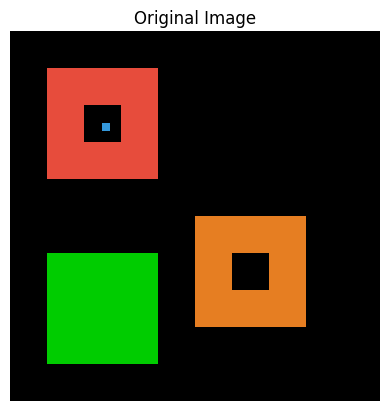

In [4]:
# display the image
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

### With skimage

In [ ]:
# use find_countours to find contours in the image
contours_red = measure.find_contours(mask_red, 0.5)
contours_red

In [ ]:
# draw the contours on the image
plt.imshow(image)
for contour in contours_red:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=5) # contour[:, 1] is x or column, contour[:, 0] is y or row
plt.title('Contours of the red part')
plt.axis('off')
plt.show()

### Using OpenCV to find contours instead of skimage

In [5]:
# prepare masks
mask_red = mask_red.astype(np.uint8) * 255 # must be 0 and 255 for cv2.findContours
mask_orange = mask_orange.astype(np.uint8) * 255
mask_blue = mask_blue.astype(np.uint8) * 255

In [7]:
# find contours using OpenCV
contours_red_cv, hierachy_red = cv2.findContours(
    mask_red,
    mode=cv2.RETR_TREE, # retrieve all contours and reconstruct the full hierarchy of nested contours
    method=cv2.CHAIN_APPROX_SIMPLE
)

hierachy_red = hierachy_red[0] # remove extra dimension

contours_red_cv, hierachy_red

((array([[[10, 10]],
  
         [[10, 39]],
  
         [[39, 39]],
  
         [[39, 10]]], dtype=int32),
  array([[[19, 20]],
  
         [[20, 19]],
  
         [[29, 19]],
  
         [[30, 20]],
  
         [[30, 29]],
  
         [[29, 30]],
  
         [[20, 30]],
  
         [[19, 29]]], dtype=int32)),
 array([[-1, -1,  1, -1],
        [-1, -1, -1,  0]], dtype=int32))

In [ ]:
assert len(contours_red_cv) == len(hierachy_red)

In [ ]:
def build_hierachy(contours, hierachy):
    nodes = []

    for i, cnt in enumerate(contours):
        nodes.append({
            "contour": cnt.squeeze(),
            "children": [],
            "parent": hierachy[i][3] # parent index
        })

    # link children to parents
    for i, h in enumerate(hierachy):
        parent_idx = h[3]
        if parent_idx != -1: # if it has a parent
            nodes[parent_idx]["children"].append(i) # add index of child

    return nodes

In [ ]:
def extract_polygons(nodes, idx, is_outer=True):
    node = nodes[idx]

    polygon = {
        "shell": node["contour"],
        "holes": []
    }

    for child_idx in node["children"]:
        if is_outer:
            # children of outer = holes
            hole = nodes[child_idx]["contour"]
            polygon["holes"].append(hole)

            # grandchildren of outer = islands in holes
            for grandchild_idx in nodes[child_idx]["children"]:
                yield from extract_polygons(nodes, grandchild_idx, is_outer=True) # islands are also outer
        else:
            # children of inner = islands in holes
            yield from extract_polygons(nodes, child_idx, is_outer=True) # islands are also outer
    yield polygon

In [ ]:
# get polygons from contours and hierachy
nodes_red = build_hierachy(contours_red_cv, hierachy_red)
polygon_dicts_red = []

for i, node in enumerate(nodes_red):
    if node["parent"] == -1: # if it's an outer contour
        polygon_dicts_red.extend(list(extract_polygons(nodes_red, i, is_outer=True)))

polygon_dicts_red

In [ ]:
assert len(nodes_red) == len(hierachy_red)

In [ ]:
mask_green = mask_green.astype(np.uint8) * 255
contours_green_cv, hierachy_green = cv2.findContours(
    mask_green,
    mode=cv2.RETR_TREE,
    method=cv2.CHAIN_APPROX_SIMPLE
)
hierachy_green

In [ ]:
hierachy_green = hierachy_green[0]

nodes_green = build_hierachy(contours_green_cv, hierachy_green)
polygon_dicts_green = []

for i, node in enumerate(nodes_green):
    if node["parent"] == -1:
        polygon_dicts_green.extend(list(extract_polygons(nodes_green, i, is_outer=True)))

polygon_dicts_green

In [ ]:
test_mask = np.zeros_like(mask_green)
contours_test, hierachy_test = cv2.findContours(
    test_mask,
    mode=cv2.RETR_TREE,
    method=cv2.CHAIN_APPROX_SIMPLE
)
assert hierachy_test is None

## Check if OCR-D RegionType supports polygons with holes

In [ ]:
# convert the above polygon dicts to shapely Polygon objects

shapely_polygons_red = []
for poly_dict in polygon_dicts_red:
    shell = poly_dict["shell"]
    holes = poly_dict["holes"]
    shapely_poly = Polygon(shell, holes)
    shapely_polygons_red.append(shapely_poly)

shapely_polygons_red

In [ ]:
len(shapely_polygons_red[0].interiors)

In [ ]:
# create coords for OCR-D TextRegionType
coords = CoordsType(points_from_polygon(shapely_polygons_red[0].interiors[0].coords))
coords.points